<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/04_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Loading

In [1]:
import os
import os.path
import time
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
os.getcwd()

'/content'

In [3]:
data_path = '/content/drive/My Drive/IDX Exchange/outputs'

In [4]:
train = pd.read_csv(os.path.join(data_path, 'crmls_sfr_train_X12_2025-04_to_2026-03.csv'))
validation = pd.read_csv(os.path.join(data_path, 'crmls_sfr_validation_2026-04.csv'))
test = pd.read_csv(os.path.join(data_path, 'crmls_sfr_test_2026-05.csv'))

In [5]:
train.shape

(121186, 156)

In [6]:
train.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail',
       ...
       'PropertyAge_scaled', 'GarageSpaces_scaled', 'ParkingTotal_scaled',
       'Latitude_scaled', 'Longitude_scaled', 'AssociationFee_scaled',
       'Stories_scaled', 'month_sin_scaled', 'month_cos_scaled', 'split'],
      dtype='object', length=156)

## 2. Feature Identification

*   **Intrinsic Property Characteristics**:
    *   `LivingArea`: Square footage
    *   `BedroomsTotal`: Number of bedrooms
    *   `BathroomsTotalDecimal`: Number of bathrooms
    *   `LotSizeSquareFeet`: Lot size
    *   `PropertyAge_scaled`: Age of the property (already scaled)

*   **Location Features**:
    *   `Latitude_scaled`: Latitude (already scaled)
    *   `Longitude_scaled`: Longitude (already scaled)

*   **Temporal Features**:
    *   `month_sin_scaled`: Sine component for sale month (already scaled, captures seasonality)
    *   `month_cos_scaled`: Cosine component for sale month (already scaled, captures seasonality)

*   **Categorical Features (for Encoding)**:
    *   `ViewYN`: Presence of a view (Yes/No)
    *   `WaterfrontYN`: Presence of waterfront (Yes/No)
    *   `BasementYN`: Presence of a basement (Yes/No)
    *   `PoolPrivateYN`: Presence of a private pool (Yes/No)
    ......

In [7]:
# Numerical fields that are relevant for pricing or data-quality review.
# ClosePrice is included for summary checks but excluded from feature scaling later.
KEY_NUMERIC_COLS = [
    "ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "PropertyAge", "GarageSpaces", "ParkingTotal",
    "Latitude", "Longitude", "AssociationFee", "FireplacesTotal", "Stories",
    "zip_median_price_per_sqft", # New engineered feature
    "month_sin", "month_cos" # Cyclical month features
]

# Binary listing attributes. These are amenity-like fields where values should become 0/1.
BINARY_COLS = [
    "ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN", "latfilled", "lonfilled",
]

# Low-cardinality categorical fields can be one-hot encoded without creating too many columns.
LOW_CARDINALITY_CATEGORICAL_COLS = [
    "Levels", "AssociationFeeFrequency", "StateOrProvince",
]

# Higher-cardinality geographic fields are frequency encoded later.
# This keeps useful market-location signal without creating hundreds of dummy columns.
FREQUENCY_CATEGORICAL_COLS = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "HighSchoolDistrict", "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict",
]

# These fields are identifiers, names, addresses, or agent/office fields.
# They are kept in the audit data but should not be treated as stable model features.
DROP_FROM_MODEL = [
    "ListingKey", "ListingKeyNumeric", "ListingId", "UnparsedAddress", "ListAgentEmail",
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "ListOfficeName", "BuyerOfficeName", "CoListOfficeName",
    "BuilderName", "SubdivisionName", "StreetNumberNumeric",
    "ListPrice", "OriginalListPrice", # Excluded as requested
    "DaysOnMarket", # Excluded as requested
    "ContractStatusChangeDate", "PurchaseContractDate", # Excluded as closing/settlement fields
    'BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'CloseDate',
    'PropertyType', 'MlsStatus', 'ElementarySchool', 'PropertySubType',
    'BuyerOfficeAOR', 'CoBuyerAgentFirstName', 'ListingContractDate',
    'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions',
    'close_month', 'split']

## 3. Feature Engineering: Handling Categorical Features

To prepare the data for the linear regression model, we will encode the categorical features.
Low-cardinality categorical features will be one-hot encoded, and higher-cardinality categorical features will be frequency encoded.

In [8]:
# One-hot encode low-cardinality categorical features
print(f"Applying One-Hot Encoding to: {LOW_CARDINALITY_CATEGORICAL_COLS}")

for col in LOW_CARDINALITY_CATEGORICAL_COLS:
    # Get all unique categories from the training set for the current column
    # Ensure 'category' dtype to handle potential missing categories in other sets gracefully
    all_categories = train[col].astype('category').cat.categories

    # Convert columns to CategoricalDtype with all known categories
    train_cat = train[col].astype(pd.CategoricalDtype(categories=all_categories))
    val_cat = validation[col].astype(pd.CategoricalDtype(categories=all_categories))
    test_cat = test[col].astype(pd.CategoricalDtype(categories=all_categories))

    # Apply one-hot encoding
    train_encoded = pd.get_dummies(train_cat, prefix=f'{col}_oh', drop_first=True)
    val_encoded = pd.get_dummies(val_cat, prefix=f'{col}_oh', drop_first=True)
    test_encoded = pd.get_dummies(test_cat, prefix=f'{col}_oh', drop_first=True)

    # Concatenate the new dummy variables with the existing dataframes and drop original column
    train = pd.concat([train.drop(columns=[col]), train_encoded], axis=1)
    validation = pd.concat([validation.drop(columns=[col]), val_encoded], axis=1)
    test = pd.concat([test.drop(columns=[col]), test_encoded], axis=1)

print("One-Hot Encoding complete.")


Applying One-Hot Encoding to: ['Levels', 'AssociationFeeFrequency', 'StateOrProvince']
One-Hot Encoding complete.


In [9]:
# Frequency encode high-cardinality categorical features
print(f"Applying Frequency Encoding to: {FREQUENCY_CATEGORICAL_COLS}")

for col in FREQUENCY_CATEGORICAL_COLS:
    # Calculate frequencies from the training data
    freq_map = train[col].value_counts(normalize=True).to_dict()

    # Apply frequency encoding to all datasets
    # Fillna(0) for categories in validation/test that are not present in train
    train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
    validation[f'{col}_freq'] = validation[col].map(freq_map).fillna(0)
    test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)

    # Drop the original categorical column
    train = train.drop(columns=[col])
    validation = validation.drop(columns=[col])
    test = test.drop(columns=[col])

print("Frequency Encoding complete.")

# Display the shapes of the dataframes after encoding to confirm changes
print(f"\nTrain shape after encoding: {train.shape}")
print(f"Validation shape after encoding: {validation.shape}")
print(f"Test shape after encoding: {test.shape}")


Applying Frequency Encoding to: ['City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict']
Frequency Encoding complete.

Train shape after encoding: (121186, 175)
Validation shape after encoding: (8151, 175)
Test shape after encoding: (11881, 175)


## 4. Linear Regression Model Training and Evaluation

This section trains a simple linear regression model on the preprocessed training data. The model's performance will be evaluated on both the validation and test sets using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define target and features
TARGET_COL = 'ClosePrice'

feature_columns = [
    c for c in train.columns
    if c not in DROP_FROM_MODEL + [TARGET_COL]
]

X_train = train[feature_columns]
y_train = train[TARGET_COL]

X_val = validation[feature_columns]
y_val = validation[TARGET_COL]

X_test = test[feature_columns]
y_test = test[TARGET_COL]

print(f"Number of features: {len(feature_columns)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Number of features: 134
X_train shape: (121186, 134)
y_train shape: (121186,)
X_val shape: (8151, 134)
y_val shape: (8151,)
X_test shape: (11881, 134)
y_test shape: (11881,)


## 5. Handling Missing Values (NaNs)

As identified, the datasets still contain missing values, which prevent the linear regression model from training. We will now handle these NaNs by:
1. Dropping columns that have a very high percentage of missing values (e.g., more than 90%).
2. Imputing the remaining numerical NaN values with the mean of their respective columns from the training set, to avoid data leakage.

In [11]:
# Calculate the percentage of NaN values for each column in X_train
nan_percentage = X_train.isnull().sum() / len(X_train) * 100
print("Percentage of NaN values in X_train for each column:\n", nan_percentage[nan_percentage > 0])

# Identify columns with more than 90% NaN values to drop
columns_to_drop_high_nan = nan_percentage[nan_percentage > 90].index.tolist()

print(f"\nColumns to drop due to high NaN percentage (>90%): {columns_to_drop_high_nan}")

# Drop these columns from X_train, X_val, and X_test
X_train = X_train.drop(columns=columns_to_drop_high_nan)
X_val = X_val.drop(columns=columns_to_drop_high_nan)
X_test = X_test.drop(columns=columns_to_drop_high_nan)

print(f"\nShapes after dropping high NaN columns: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")

Percentage of NaN values in X_train for each column:
 FireplacesTotal           100.000000
AboveGradeFinishedArea    100.000000
TaxAnnualAmount           100.000000
LotSizeAcres                1.741125
TaxYear                   100.000000
BuildingAreaTotal          93.482746
BelowGradeFinishedArea     99.321704
BusinessType              100.000000
CoveredSpaces             100.000000
LotSizeArea                 1.738650
MainLevelBedrooms          39.277639
dtype: float64

Columns to drop due to high NaN percentage (>90%): ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'TaxYear', 'BuildingAreaTotal', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces']

Shapes after dropping high NaN columns: X_train=(121186, 126), X_val=(8151, 126), X_test=(11881, 126)


In [12]:
# Identify remaining columns with NaN values
remaining_nan_cols = X_train.isnull().sum()[X_train.isnull().sum() > 0].index.tolist()
print(f"\nRemaining columns with NaNs to impute: {remaining_nan_cols}")

# Impute remaining NaN values with the mean from the training set
for col in remaining_nan_cols:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_val[col] = X_val[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

print("\nNaN imputation complete. Verifying no NaNs remain:")
print("NaNs in X_train after imputation:", X_train.isnull().sum().sum())
print("NaNs in X_val after imputation:", X_val.isnull().sum().sum())
print("NaNs in X_test after imputation:", X_test.isnull().sum().sum())


Remaining columns with NaNs to impute: ['LotSizeAcres', 'LotSizeArea', 'MainLevelBedrooms']

NaN imputation complete. Verifying no NaNs remain:
NaNs in X_train after imputation: 0
NaNs in X_val after imputation: 0
NaNs in X_test after imputation: 0


## Linear Regression Model

In [13]:
linear_model = LinearRegression()
linear_model_fit = linear_model.fit(X_train, y_train)

print("Linear Regression model re-trained successfully with imputed data.")

Linear Regression model re-trained successfully with imputed data.


In [16]:
# Make predictions on the validation and test sets with the re-trained model
y_val_pred = linear_model.predict(X_val)
y_test_pred = linear_model.predict(X_test)

# Evaluate model performance on validation set
print("\nValidation Set Metrics (after imputation):")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):,.2f}")
print(f"MSE: {mean_squared_error(y_val, y_val_pred):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):,.2f}")
print(f"R-squared: {r2_score(y_val, y_val_pred):.4f}")

# Evaluate model performance on test set
print("\nTest Set Metrics (after imputation):")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):,.2f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"R-squared: {r2_score(y_test, y_test_pred):.4f}")


Validation Set Metrics (after imputation):
MAE: 392,172.52
MSE: 365,398,467,136.04
RMSE: 604,481.98
R-squared: 0.6245

Test Set Metrics (after imputation):
MAE: 396,341.06
MSE: 362,741,175,799.20
RMSE: 602,279.98
R-squared: 0.6315


## 6. Enhanced Model Evaluation Metrics

To provide a more comprehensive evaluation of the linear regression model's performance, we will calculate and report additional metrics, specifically the Mean Absolute Percentage Error (MAPE) and Median Absolute Percentage Error (MdAPE), alongside the previously calculated R-squared (R²) and Mean Absolute Error (MAE).

In [18]:
from sklearn.metrics import mean_absolute_percentage_error

def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate additional metrics for validation set
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100
md_ape_val = median_absolute_percentage_error(y_val, y_val_pred)

# Calculate additional metrics for test set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100
md_ape_test = median_absolute_percentage_error(y_test, y_test_pred)

# Report all metrics together
print("\n--- Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val:.4f}")
print(f"  MAE: {mae_val:,.2f}")
print(f"  MAPE: {mape_val:,.2f}%")
print(f"  MdAPE: {md_ape_val:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test:.4f}")
print(f"  MAE: {mae_test:,.2f}")
print(f"  MAPE: {mape_test:,.2f}%")
print(f"  MdAPE: {md_ape_test:,.2f}%")



--- Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.6245
  MAE: 392,172.52
  MAPE: 35.78%
  MdAPE: 25.32%

Test Set Metrics:
  R-squared: 0.6315
  MAE: 396,341.06
  MAPE: 39.66%
  MdAPE: 27.07%


## 7. Residual Analysis

Visualizing the residuals can help identify patterns or issues with the model's predictions.

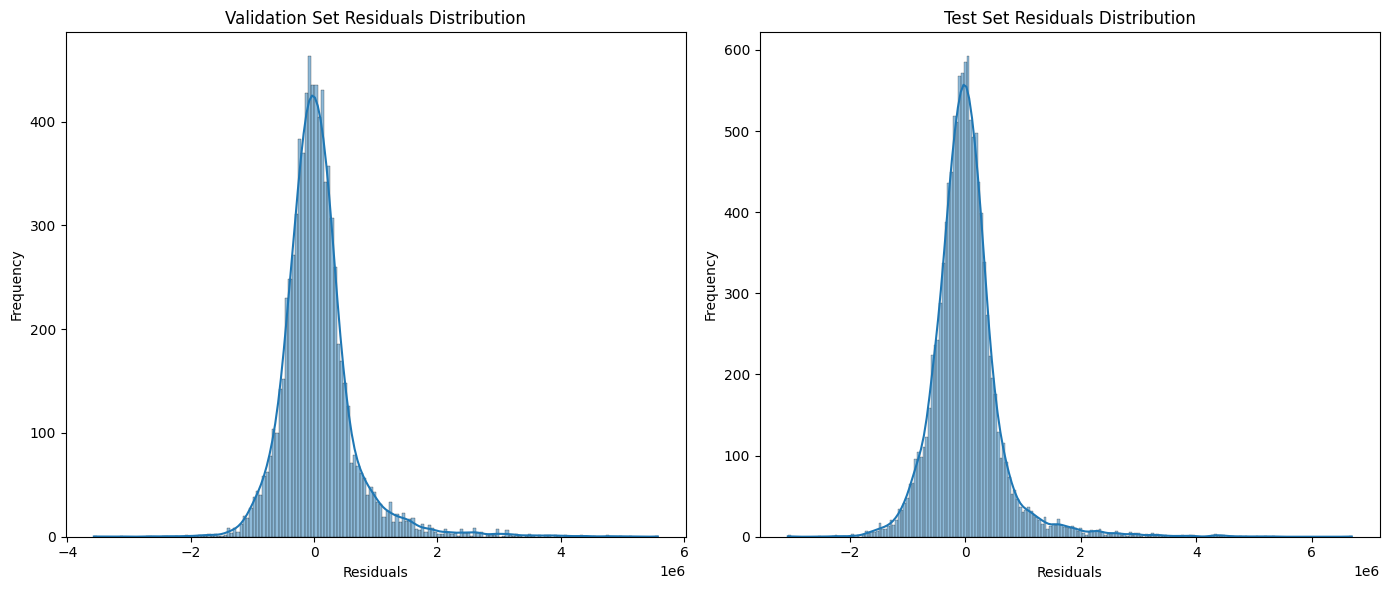

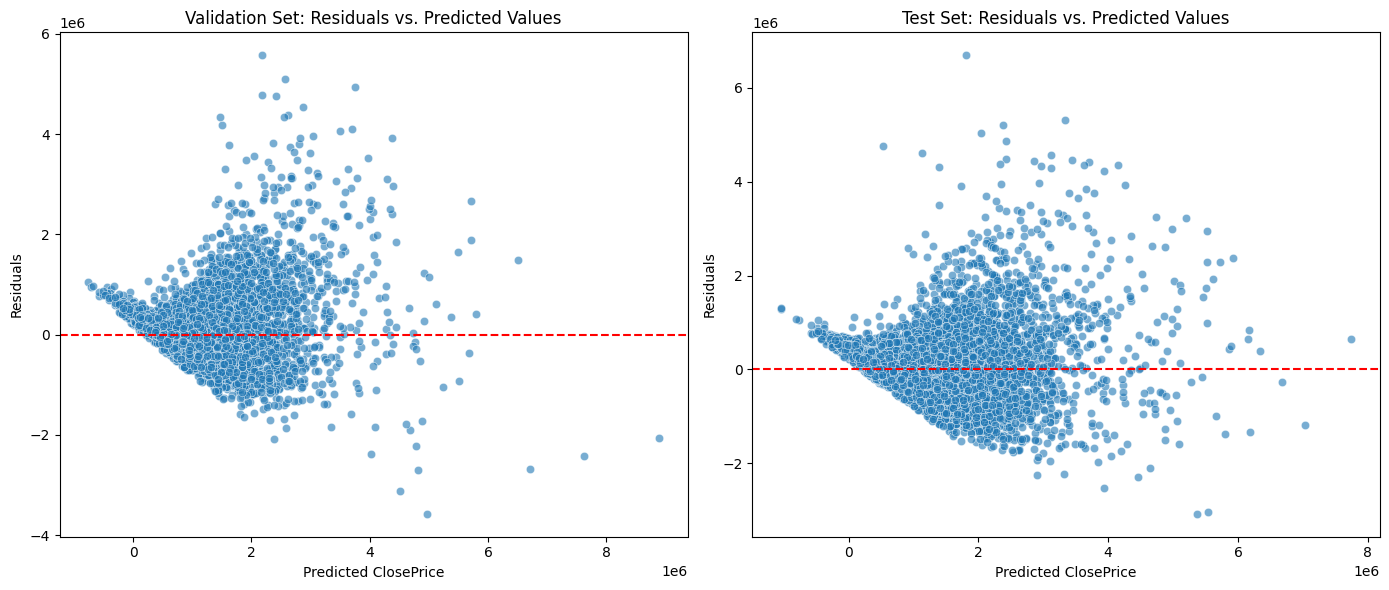

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for residuals
residuals_df_val = pd.DataFrame({
    'Actual': y_val,
    'Predicted': y_val_pred,
    'Residuals': y_val - y_val_pred
})

residuals_df_test = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Residuals': y_test - y_test_pred
})

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(residuals_df_val['Residuals'], kde=True)
plt.title('Validation Set Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(residuals_df_test['Residuals'], kde=True)
plt.title('Test Set Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Predicted', y='Residuals', data=residuals_df_val, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Validation Set: Residuals vs. Predicted Values')
plt.xlabel('Predicted ClosePrice')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Predicted', y='Residuals', data=residuals_df_test, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Test Set: Residuals vs. Predicted Values')
plt.xlabel('Predicted ClosePrice')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

## 8. Decision Tree Regressor Model Training and Evaluation

In [20]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42) # Using a random_state for reproducibility
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


In [21]:
# Make predictions on the validation and test sets
y_val_pred_dt = decision_tree_model.predict(X_val)
y_test_pred_dt = decision_tree_model.predict(X_test)

# Evaluate model performance on validation set
mae_val_dt = mean_absolute_error(y_val, y_val_pred_dt)
mse_val_dt = mean_squared_error(y_val, y_val_pred_dt)
rmse_val_dt = np.sqrt(mse_val_dt)
r2_val_dt = r2_score(y_val, y_val_pred_dt)
mape_val_dt = mean_absolute_percentage_error(y_val, y_val_pred_dt) * 100
md_ape_val_dt = median_absolute_percentage_error(y_val, y_val_pred_dt)

# Evaluate model performance on test set
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
rmse_test_dt = np.sqrt(mse_test_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)
mape_test_dt = mean_absolute_percentage_error(y_test, y_test_pred_dt) * 100
md_ape_test_dt = median_absolute_percentage_error(y_test, y_test_pred_dt)

print("\n--- Decision Tree Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_dt:.4f}")
print(f"  MAE: {mae_val_dt:,.2f}")
print(f"  MAPE: {mape_val_dt:,.2f}%")
print(f"  MdAPE: {md_ape_val_dt:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_dt:.4f}")
print(f"  MAE: {mae_test_dt:,.2f}")
print(f"  MAPE: {mape_test_dt:,.2f}%")
print(f"  MdAPE: {md_ape_test_dt:,.2f}%")


--- Decision Tree Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.7559
  MAE: 250,563.86
  MAPE: 17.81%
  MdAPE: 11.58%

Test Set Metrics:
  R-squared: 0.7498
  MAE: 245,053.49
  MAPE: 18.05%
  MdAPE: 11.55%


## 9. Random Forest Regressor Model Training and Evaluation

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Using n_jobs=-1 to utilize all available cores
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [23]:
# Make predictions on the validation and test sets
y_val_pred_rf = random_forest_model.predict(X_val)
y_test_pred_rf = random_forest_model.predict(X_test)

# Evaluate model performance on validation set
mae_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
mse_val_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_val_rf = np.sqrt(mse_val_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
mape_val_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf) * 100
md_ape_val_rf = median_absolute_percentage_error(y_val, y_val_pred_rf)

# Evaluate model performance on test set
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
mape_test_rf = mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100
md_ape_test_rf = median_absolute_percentage_error(y_test, y_test_pred_rf)

print("\n--- Random Forest Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_rf:.4f}")
print(f"  MAE: {mae_val_rf:,.2f}")
print(f"  MAPE: {mape_val_rf:,.2f}%")
print(f"  MdAPE: {md_ape_val_rf:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_rf:.4f}")
print(f"  MAE: {mae_test_rf:,.2f}")
print(f"  MAPE: {mape_test_rf:,.2f}%")
print(f"  MdAPE: {md_ape_test_rf:,.2f}%")


--- Random Forest Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.8753
  MAE: 174,153.08
  MAPE: 12.32%
  MdAPE: 7.96%

Test Set Metrics:
  R-squared: 0.8709
  MAE: 175,557.98
  MAPE: 12.91%
  MdAPE: 8.14%


## 10. Model Comparison and Analysis

Now, let's compare the performance of the Linear Regression, Decision Tree, and Random Forest models using the evaluation metrics calculated on both the validation and test sets. We'll summarize the key metrics to facilitate comparison and then discuss the observed strengths and weaknesses of each model.

In [24]:
model_comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Validation R-squared': [r2_val, r2_val_dt, r2_val_rf],
    'Validation MAE': [mae_val, mae_val_dt, mae_val_rf],
    'Validation MAPE': [mape_val, mape_val_dt, mape_val_rf],
    'Validation MdAPE': [md_ape_val, md_ape_val_dt, md_ape_val_rf],
    'Test R-squared': [r2_test, r2_test_dt, r2_test_rf],
    'Test MAE': [mae_test, mae_test_dt, mae_test_rf],
    'Test MAPE': [mape_test, mape_test_dt, mape_test_rf],
    'Test MdAPE': [md_ape_test, md_ape_test_dt, md_ape_test_rf]
}

model_comparison_df = pd.DataFrame(model_comparison_data)

# Format the numerical columns for better readability
for col in model_comparison_df.columns:
    if 'R-squared' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:.4f}'.format)
    elif 'MAE' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:,.2f}'.format)
    elif 'MAPE' in col or 'MdAPE' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:,.2f}%'.format)

display(model_comparison_df)


,Model,Validation R-squared,Validation MAE,Validation MAPE,Validation MdAPE,Test R-squared,Test MAE,Test MAPE,Test MdAPE
0,Linear Regression,0.6245,"392,172.52",35.78%,25.32%,0.6315,"396,341.06",39.66%,27.07%
1,Decision Tree,0.7559,"250,563.86",17.81%,11.58%,0.7498,"245,053.49",18.05%,11.55%
2,Random Forest,0.8753,"174,153.08",12.32%,7.96%,0.8709,"175,557.98",12.91%,8.14%


## 11. Model Behavior: Strengths and Weaknesses

Based on the comparison table, we can observe the following:

**1. Linear Regression (Baseline Model)**
*   **Strengths**: Simplicity, ease of interpretation of coefficients, and fast training times. It provides a good initial benchmark. The R-squared values around 0.62-0.63 indicate it captures a fair amount of variance.
*   **Weaknesses**: Lower predictive performance compared to tree-based models, especially indicated by higher MAE, MAPE, and MdAPE. It assumes a linear relationship between features and the target, which might not always hold true in complex real estate datasets. It is also sensitive to outliers and multicollinearity.

**2. Decision Tree Regressor**
*   **Strengths**: Improved performance over Linear Regression (R-squared around 0.75, significantly lower MAE, MAPE, and MdAPE). It can capture non-linear relationships and interactions between features without explicit feature engineering. The model is relatively easy to understand and visualize for smaller trees.
*   **Weaknesses**: Decision Trees are prone to overfitting, especially deep trees, which can lead to poor generalization on unseen data. They can be unstable; small changes in the data can lead to a completely different tree structure. This can be seen in the slight drop in R-squared from validation to test, though it's relatively stable here.

**3. Random Forest Regressor**
*   **Strengths**: Significantly better performance than both Linear Regression and Decision Tree (R-squared around 0.87, lowest MAE, MAPE, and MdAPE). It addresses the overfitting issue of individual Decision Trees by averaging multiple trees (ensemble method), leading to more robust and accurate predictions. It handles high-dimensional data well and is less prone to overfitting than single decision trees.
*   **Weaknesses**: While highly accurate, Random Forests are more complex and less interpretable than single Decision Trees or Linear Regression. The training process can be computationally more expensive and slower, especially with a large number of trees or features. Tuning hyperparameters can also be more involved.